# Expansion cases, sensitivity and 2030–2032

Indonesia only. A/E/B/S labels and source boundaries remain in datasets. These calculations are scenarios, not metered national data-center electricity or water. See docs/methodology.md.

In [1]:
from pathlib import Path
import sys
root = Path.cwd().resolve()
while not (root / 'assumptions.yaml').exists():
    if root == root.parent: raise FileNotFoundError('Run from within the research repository')
    root = root.parent
sys.path.insert(0, str(root / 'src'))
import pandas as pd
from IPython.display import display, Image
from config import read_dataset, assumptions


In [2]:
display(read_dataset('additional_1gw'))
display(read_dataset('outlook_2030_2032')[['outlook_case','year','it_capacity_mw','facility_electricity_twh','water_m3_per_year','share_national_consumption_pct','scenario_share_national_consumption_pct','data_class']])

,case,it_capacity_mw,it_capacity_gw,utilization,pue,wue_l_per_kwh,electricity_tariff_rp_per_kwh,water_tariff_rp_per_m3,it_electricity_mwh,it_electricity_gwh,...,notes,national_denominator_year,national_consumption_twh,pln_sales_twh,national_denominator_source_id,denominator_data_class,share_national_consumption_pct,share_pln_sales_pct,equivalent_continuous_generation_gw,generation_capacity_gw_at_assumed_capacity_factor
0,low,1000,1,0.60,1.2,0.0,996.74,21500,5256000,5256,...,Annual steady-state run rate. Energy charges o...,2025,455.001,317.692,ELEC001,A,1.386195,1.985319,0.720,0.90000
1,base,1000,1,0.80,1.3,0.5,996.74,21500,7008000,7008,...,Annual steady-state run rate. Energy charges o...,2025,455.001,317.692,ELEC001,A,2.002281,2.867683,1.040,1.30000
2,high,1000,1,0.95,1.5,1.5,996.74,21500,8322000,8322,...,Annual steady-state run rate. Energy charges o...,2025,455.001,317.692,ELEC001,A,2.743510,3.929277,1.425,1.78125


,outlook_case,year,it_capacity_mw,facility_electricity_twh,water_m3_per_year,share_national_consumption_pct,scenario_share_national_consumption_pct,data_class
0,Conservative,2030,640.750,4.041338,0.0,0.888204,0.663718,S
1,Conservative,2031,692.375,4.366948,0.0,0.959767,0.676598,S
2,Conservative,2032,744.000,4.692557,0.0,1.031329,0.685893,S
3,Base Case,2030,1956.000,17.819942,6853824.0,3.916462,2.926608,S
4,Base Case,2031,2319.600,21.132484,8127878.4,4.644492,3.274183,S
5,Base Case,2032,2683.200,24.445025,9401932.8,5.372521,3.573033,S
6,Aggressive AI Boom,2030,3168.000,39.546144,39546144.0,8.691441,6.494750,S
7,Aggressive AI Boom,2031,3168.000,39.546144,39546144.0,8.691441,6.127123,S
8,Aggressive AI Boom,2032,3168.000,39.546144,39546144.0,8.691441,5.780305,S


In [3]:
from copy import deepcopy
from scenario_model import evaluate
a = deepcopy(assumptions())
a['scenarios']['base']['pue'] = 1.4
original = evaluate(1000, 'base')
changed = evaluate(1000, 'base', a)
assert changed['facility_electricity_gwh'] > original['facility_electricity_gwh']
assert changed['water_m3_per_year'] == original['water_m3_per_year']
display(pd.DataFrame([original, changed])[['pue','facility_electricity_gwh','water_m3_per_year','total_resource_cost_rp']])

,pue,facility_electricity_gwh,water_m3_per_year,total_resource_cost_rp
0,1.3,9110.4,3504000.0,9.156036e+12
1,1.4,9811.2,3504000.0,9.854551e+12


,driver,driver_value,facility_electricity_gwh,electricity_cost_rp,water_m3_per_year,water_cost_rp
0,pue,1.10,7708.8,7.683669e+12,3504000,75336000000
1,pue,1.20,8409.6,8.382185e+12,3504000,75336000000
2,pue,1.30,9110.4,9.080700e+12,3504000,75336000000
3,pue,1.40,9811.2,9.779215e+12,3504000,75336000000
4,pue,1.50,10512.0,1.047773e+13,3504000,75336000000
5,wue_l_per_kwh,0.00,9110.4,9.080700e+12,0,0
6,wue_l_per_kwh,0.20,9110.4,9.080700e+12,1401600,30134400000
7,wue_l_per_kwh,0.50,9110.4,9.080700e+12,3504000,75336000000
8,wue_l_per_kwh,1.00,9110.4,9.080700e+12,7008000,150672000000
9,wue_l_per_kwh,1.50,9110.4,9.080700e+12,10512000,226008000000


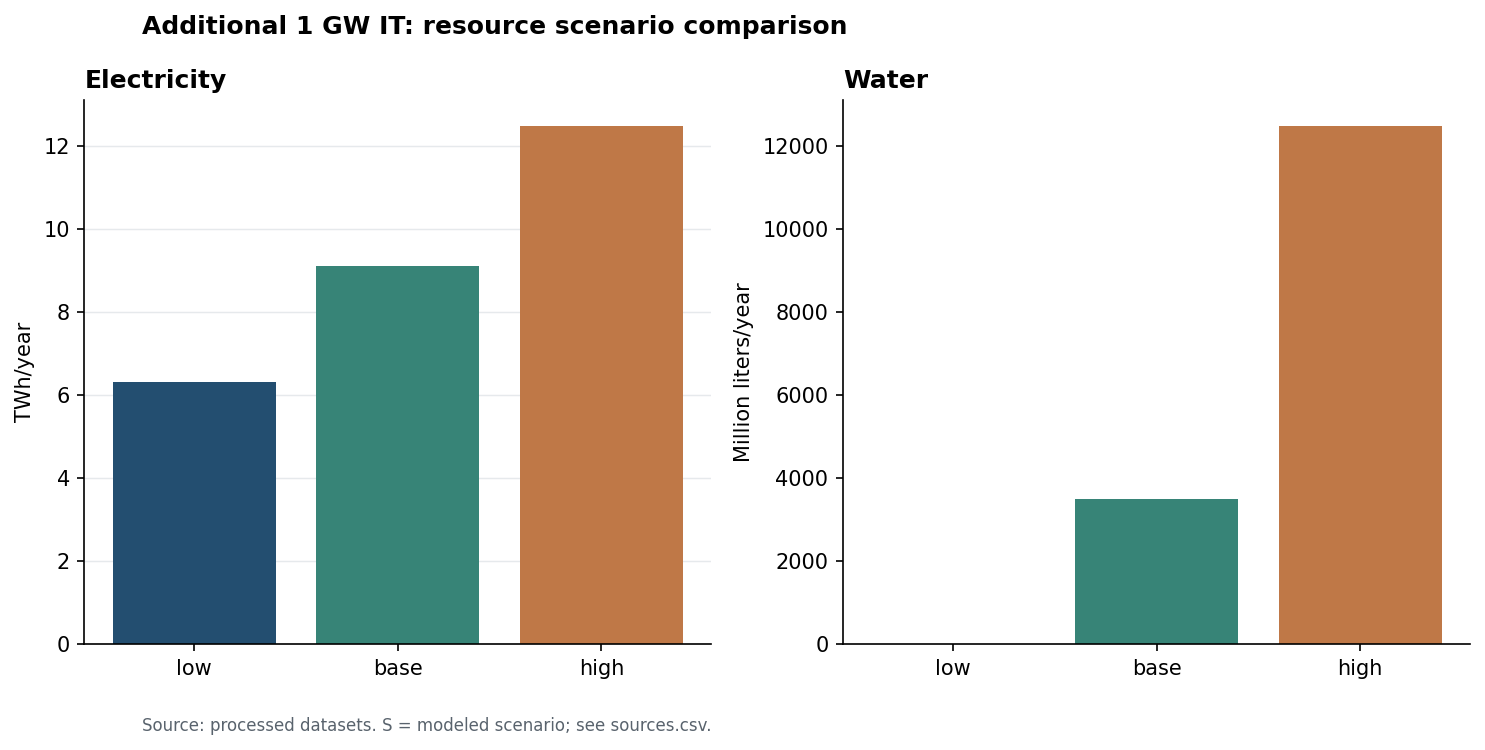

In [4]:
display(read_dataset('sensitivity')[['driver','driver_value','facility_electricity_gwh','electricity_cost_rp','water_m3_per_year','water_cost_rp']])
display(Image(filename=str(root / 'outputs/charts/11_scenario_comparison.png')))